In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df = sns.load_dataset("titanic")

In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [5]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [6]:
features = ["pclass", "age", "sex", "embarked", "fare"]
target = ["survived"]

In [7]:
# handle missing
from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy="median")
df[["age"]] = imp_median.fit_transform(df[["age"]])

imp_mean = SimpleImputer(strategy="most_frequent")
df[["embarked"]] = imp_mean.fit_transform(df[["embarked"]])

df.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["sex"] = le.fit_transform(df["sex"])
df["embarked"] = le.fit_transform(df["embarked"])

In [39]:
X = df[features]
y = df["survived"]

In [40]:
X.head()

,pclass,age,sex,embarked,fare
0,3,22.0,1,2,7.2500
1,1,38.0,0,0,71.2833
2,3,26.0,0,2,7.9250
3,1,35.0,0,2,53.1000
4,3,35.0,1,2,8.0500


In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [42]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [43]:
y_pred = model.predict(X_test)

In [44]:
from sklearn.metrics import accuracy_score

print("accuracy: ", accuracy_score(y_test, y_pred))

accuracy:  0.776536312849162


<function matplotlib.pyplot.show(close=None, block=None)>

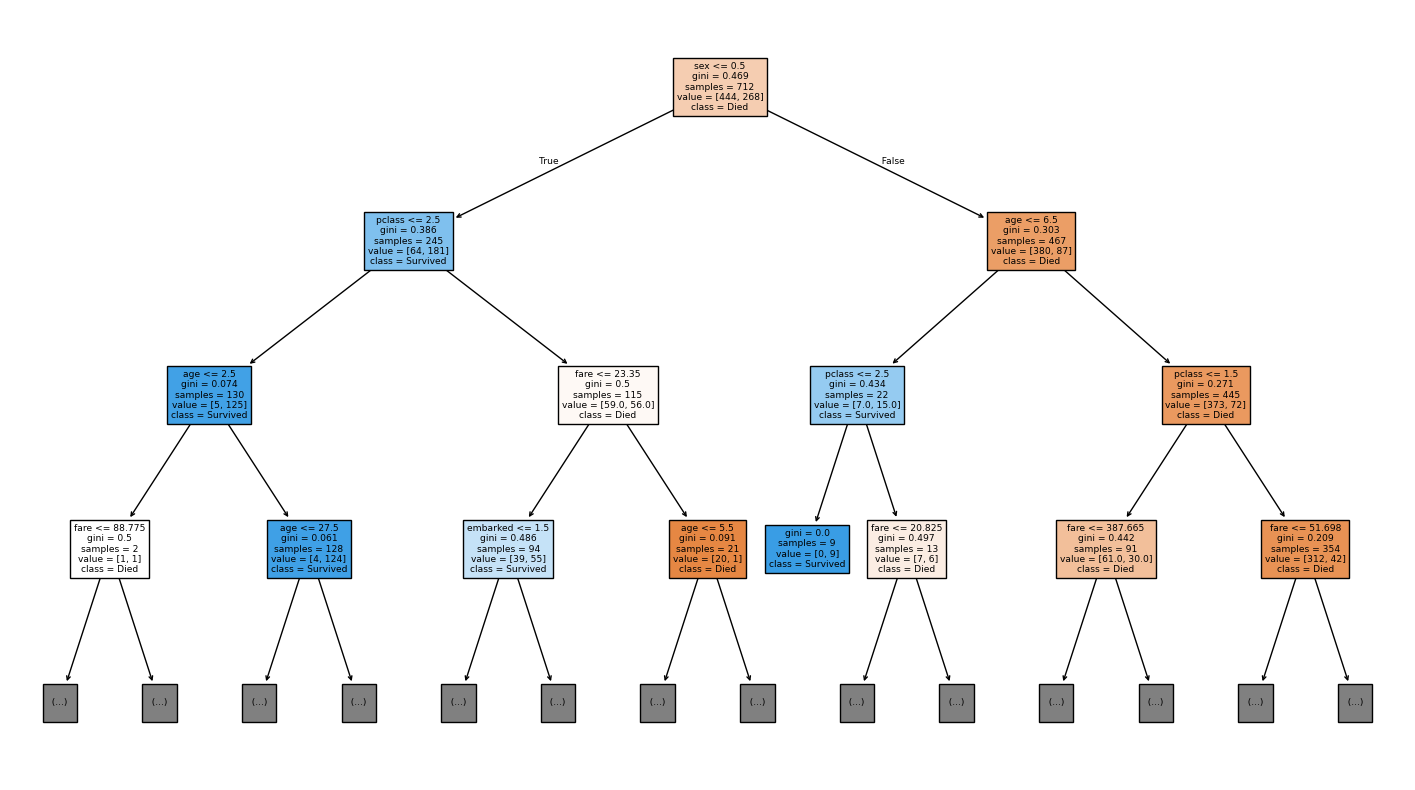

In [45]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True,
    max_depth=3
)

plt.tight_layout
plt.show

## pre-pruning

In [46]:
max_depths = [2, 3, 4, 5, 6, 7, 8, 9, 10]

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)

    print(f"accuracy for depth={depth} : {acc}")

accuracy for depth=2 : 0.7653631284916201
accuracy for depth=3 : 0.7988826815642458
accuracy for depth=4 : 0.7988826815642458
accuracy for depth=5 : 0.7988826815642458
accuracy for depth=6 : 0.7988826815642458
accuracy for depth=7 : 0.7877094972067039
accuracy for depth=8 : 0.7932960893854749
accuracy for depth=9 : 0.7932960893854749
accuracy for depth=10 : 0.7877094972067039


In [47]:
min_samples_split = [5, 10, 15, 20, 25, 30]

for split in min_samples_split:
    model = DecisionTreeClassifier(min_samples_split=split)
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)

    print(f"accuracy for split={split} : {acc}")

accuracy for split=5 : 0.7821229050279329
accuracy for split=10 : 0.8156424581005587
accuracy for split=15 : 0.8156424581005587
accuracy for split=20 : 0.8212290502793296
accuracy for split=25 : 0.8044692737430168
accuracy for split=30 : 0.7988826815642458


## post-pruning

In [48]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [49]:
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 6.68806849e-05 1.45921494e-04
 1.84428555e-04 2.00642055e-04 2.34082397e-04 2.34082397e-04
 3.51123596e-04 4.68164794e-04 4.68164794e-04 5.61797753e-04
 6.24219725e-04 6.67991230e-04 7.02247191e-04 7.02247191e-04
 8.19288390e-04 8.19288390e-04 8.32292967e-04 8.42696629e-04
 8.42696629e-04 8.42696629e-04 8.94231048e-04 8.99610781e-04
 9.24769963e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 9.88347898e-04 1.00253471e-03 1.05337079e-03 1.07400895e-03
 1.08038029e-03 1.11865144e-03 1.12359551e-03 1.12359551e-03
 1.13139825e-03 1.17041199e-03 1.18841832e-03 1.22566125e-03
 1.22893258e-03 1.22893258e-03 1.24361593e-03 1.24843945e-03
 1.27565833e-03 1.30996111e-03 1.33761370e-03 1.37044603e-03
 1.46301498e-03 1.47927070e-03 1.51142557e-03 1.54072312e-03
 1.56675436e-03 1.60434338e-03 1.66892062e-03 1.76144762e-03
 1.86751451e-03 2.10674157e-03 2.34082397e-03 2.41226470e-03
 2.64273538e-03 2.69412911e-03 3.43770913e-03 3.56327570e-03
 5.47433606e-03 9.055400

In [50]:
# train model for all alphas

trees = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(X_train, y_train)
    
    trees.append((model, alpha))

In [51]:
best_acc = 0
best_alpha = 0

for model, alpha in trees:
    curr_acc = model.score(X_test, y_test)
    if curr_acc > best_acc:
        best_acc = curr_acc
        best_alpha = alpha

In [52]:
print("best_alpha: ", best_alpha)
print("best_acc: ", best_acc)

best_alpha:  0.0015407231242023183
best_acc:  0.8379888268156425


In [53]:
best_pruned_model = DecisionTreeClassifier(ccp_alpha=best_alpha)
best_pruned_model.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.0015407231242023183)

<function matplotlib.pyplot.show(close=None, block=None)>

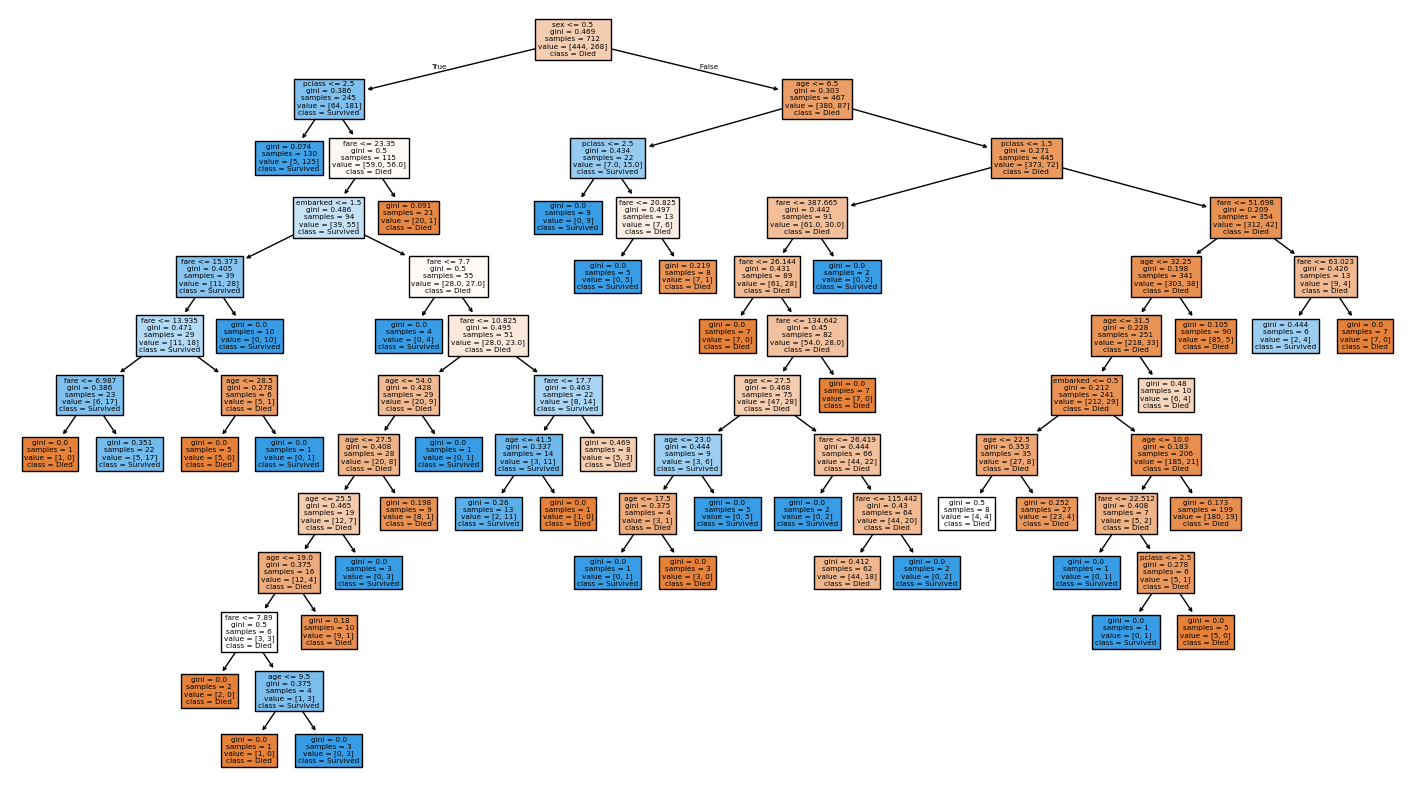

In [54]:
plt.figure(figsize=(18, 10))

plot_tree(
    best_pruned_model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True,
)

plt.tight_layout
plt.show

In [55]:
best_pruned_model.score(X_test, y_test)

0.8379888268156425

 ## pre-pruning + post-pruning

In [56]:
best_model = DecisionTreeClassifier(ccp_alpha=best_alpha, min_samples_split=20)
best_model.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.0015407231242023183, min_samples_split=20)

<function matplotlib.pyplot.show(close=None, block=None)>

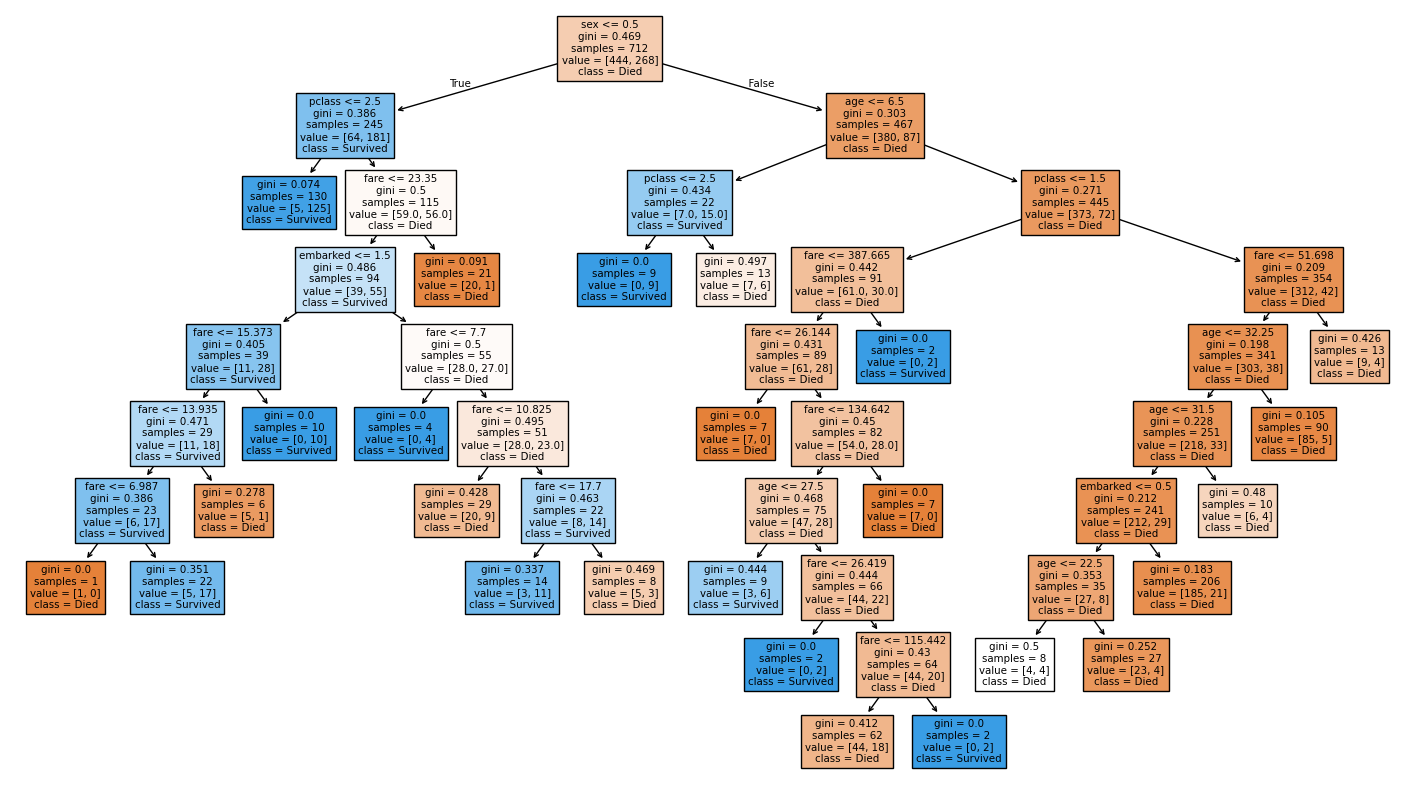

In [57]:
plt.figure(figsize=(18, 10))

plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True,
)

plt.tight_layout
plt.show

In [58]:
best_model.score(X_test, y_test)

0.8379888268156425

In [59]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print("training accuracy: ", accuracy_score(y_train, y_pred_train))
print("testing accuracy: ", accuracy_score(y_test, y_pred_test))

training accuracy:  0.6235955056179775
testing accuracy:  0.5865921787709497


*Overfitting case. 

## Random forest classifier

In [72]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=401,  # have to hyperparameter tuning to find best number of models
    oob_score=True, 
    bootstrap=True,
    max_depth=4
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=4, n_estimators=401, oob_score=True)

In [73]:
y_pred = rf.predict(X_test)

print("OOB score: ", rf.oob_score_)
print("testing accuracy: ", accuracy_score(y_test, y_pred))

OOB score:  0.8328651685393258
testing accuracy:  0.8212290502793296


### Bagging classifier

In [75]:
from sklearn.ensemble import BaggingClassifier

base_model = DecisionTreeClassifier()

bagging = BaggingClassifier(
    base_model,
    n_estimators=201
)

bagging.fit(X_train, y_train)

y_pred = bagging.predict(X_test)

print("accuracy score: ", accuracy_score(y_test, y_pred))

accuracy score:  0.7988826815642458
